
Universidade do Vale do Itajaí <br>
Escola Politécnica <br>
Processamento Digital de Sinais: Imagens <br>

### Alunos: <br>
1.      Diogo Henrique Ribicki
2.      João Victor da Silva
3.      Pedro Henrique de Paula

In [2]:
from keyword import issoftkeyword
from platform import processor

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.util import random_noise
from sympy.abc import sigma

### Carregar o DataSet

In [3]:
data = np.load('data/chestmnist.npz')

### Separar os dados

In [4]:
train_images = data['train_images']
train_labels = data['train_labels']

print("Shape das imagens:", train_images.shape)
print("Shape dos labels:", train_labels.shape)

Shape das imagens: (78468, 28, 28)
Shape dos labels: (78468, 14)


### Selecionar imagens

In [5]:
img_1 = train_images[5]
img_2 = train_images[25]
img_3 = train_images[50]

### Exibir imagens

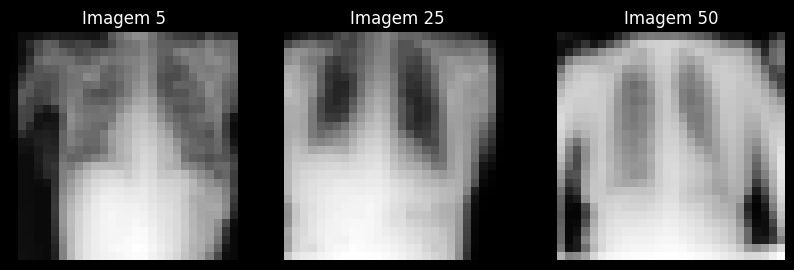

In [6]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_1, cmap='gray')
plt.title("Imagem 5")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_2, cmap='gray')
plt.title("Imagem 25")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_3, cmap='gray')
plt.title("Imagem 50")
plt.axis('off')

plt.show()

### Implementação do Trabalho

### Helpers

In [7]:
def show_images_grid(images, titles=None, cols=3, figsize=(12, 6)):
    n_images = len(images)
    rows = (n_images + cols - 1) // cols

    plt.figure(figsize=figsize)

    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap='gray')

        if titles:
            plt.title(titles[i])

        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [8]:
def add_padding(img, pad_size):
    h, w = img.shape
    padded = np.zeros((h + 2 * pad_size, w + 2 * pad_size), dtype=img.dtype)
    padded[pad_size:pad_size + h, pad_size:pad_size + w] = img
    return padded

In [9]:
def show_histogram(img, title="Histograma"):
    hist = calc_histogram(img)

    plt.figure(figsize=(8, 4))
    plt.plot(hist)
    plt.title(title)
    plt.xlabel("Nível de cinza")
    plt.ylabel("Frequência")
    plt.show()

In [10]:
def normalize_image(img):
    img = img.astype(np.float32)
    img_min = img.min()
    img_max = img.max()

    if img_max == img_min:
        return np.zeros_like(img, dtype=np.uint8)

    norm = (img - img_min) / (img_max - img_min)
    norm = norm * 255

    return norm.astype(np.uint8)

### 1 - Preparação das imagens

In [11]:
data = np.load('data/chestmnist.npz')

train_images = data['train_images']

img_1 = train_images[5].astype(np.float32)
img_2 = train_images[25].astype(np.float32)
img_3 = train_images[50].astype(np.float32)

### Funções para aplicar ruídos

In [12]:
def add_salt_pepper_noise(img, amount=0.05, salt_vs_pepper=0.5):
    noisy = img.copy()

    total_pixels = img.shape[0] * img.shape[1]
    num_noisy = int(total_pixels * amount)

    num_salt = int(num_noisy * salt_vs_pepper)
    num_pepper = num_noisy - num_salt

    # Salt (branco = 255)
    coords_salt = (
        np.random.randint(0, img.shape[0], num_salt),
        np.random.randint(0, img.shape[1], num_salt)
    )
    noisy[coords_salt] = 255

    # Pepper (preto = 0)
    coords_pepper = (
        np.random.randint(0, img.shape[0], num_pepper),
        np.random.randint(0, img.shape[1], num_pepper)
    )
    noisy[coords_pepper] = 0

    return noisy

In [13]:
def add_gaussian_noise(img, mean=0, std=15):
    noise = np.random.normal(mean, std, img.shape)
    noisy = img + noise
    noisy = np.clip(noisy, 0, 255)
    return noisy

### Cria as imagens com ruídos + exibição das imagens

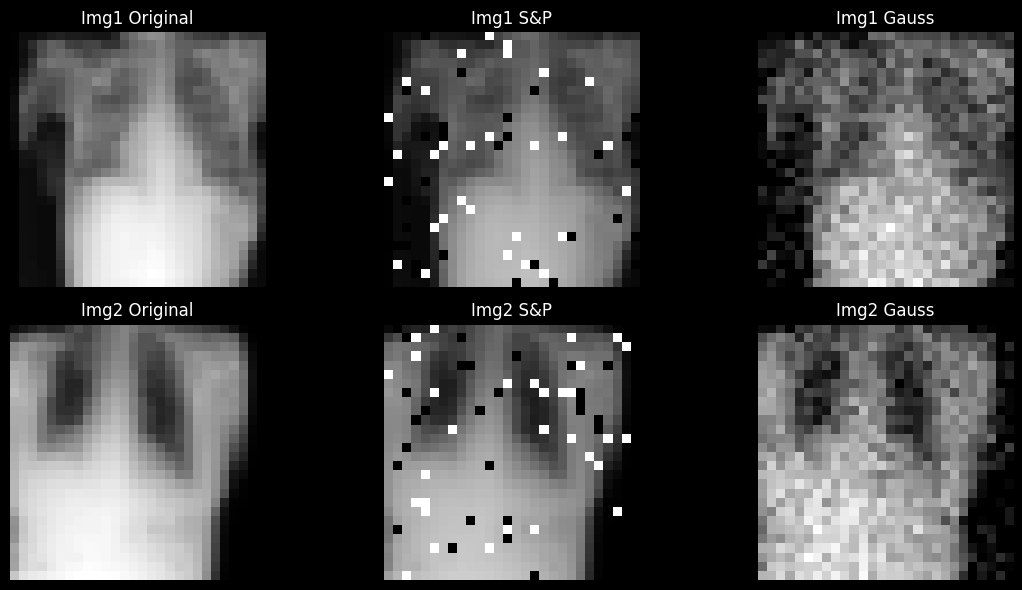

In [14]:
img_1_sp = add_salt_pepper_noise(img_1, amount=0.08)
img_2_sp = add_salt_pepper_noise(img_2, amount=0.08)
img_3_sp = add_salt_pepper_noise(img_3, amount=0.08)

img_1_gauss = add_gaussian_noise(img_1, std=20)
img_2_gauss = add_gaussian_noise(img_2, std=20)
img_3_gauss = add_gaussian_noise(img_3, std=20)

show_images_grid(
    [img_1, img_1_sp, img_1_gauss,
     img_2, img_2_sp, img_2_gauss],
    [
        "Img1 Original", "Img1 S&P", "Img1 Gauss",
        "Img2 Original", "Img2 S&P", "Img2 Gauss"
    ],
    cols=3
)

### 2 - Pré-processamento

In [15]:
def calc_histogram(img):
    hist = np.zeros(256, dtype=np.int32)

    for value in img.flatten():
        hist[int(value)] += 1

    return hist

In [16]:
def histogram_equalization(img):
    img_uint8 = img.astype(np.uint8)

    hist = calc_histogram(img_uint8)
    num_pixels = img_uint8.size

    prob = hist / num_pixels
    cdf = np.cumsum(prob)

    transform = np.floor(255 * cdf).astype(np.uint8)

    equalized = transform[img_uint8]

    return equalized

In [17]:
def gamma_correction(img, gamma=1.0, c=1.0):
    img_norm = img.astype(np.float32) / 255.0

    corrected = c * (img_norm ** gamma)
    corrected = np.clip(corrected, 0, 1)

    corrected = (corrected * 255).astype(np.uint8)

    return corrected

In [18]:
def preprocess_contrast(img, gamma=0.7):
    img_eq = histogram_equalization(img)
    img_gamma = gamma_correction(img_eq, gamma=gamma)

    return img_eq, img_gamma

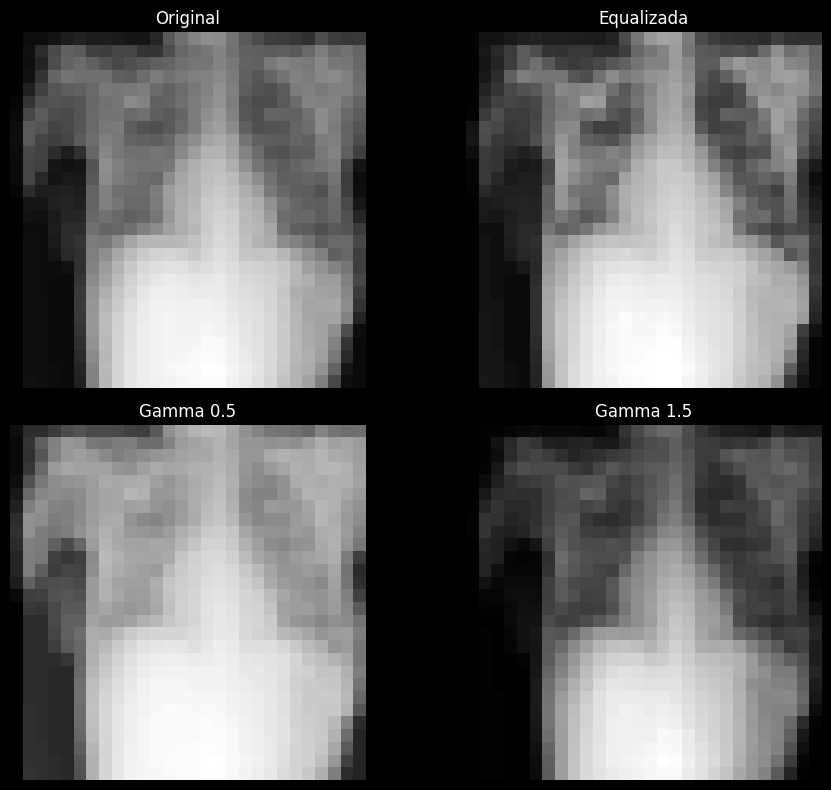

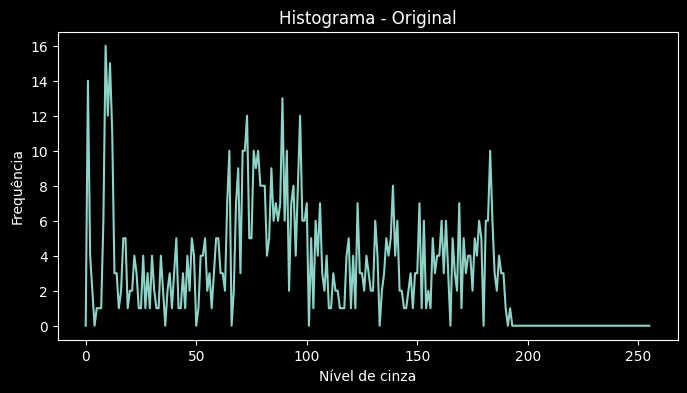

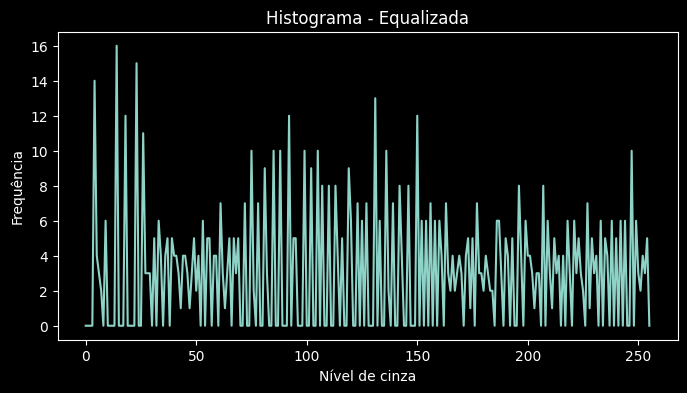

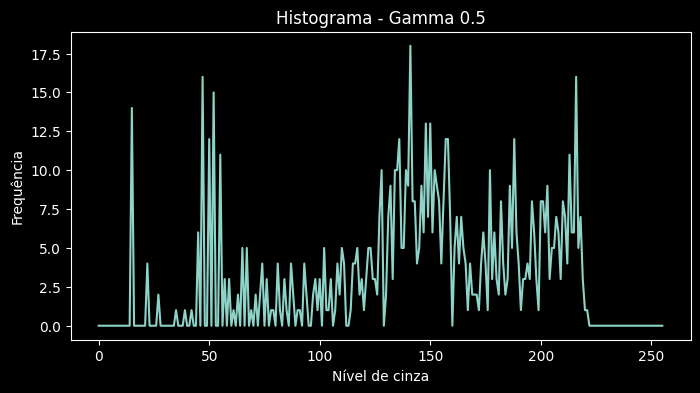

In [19]:
img_eq = histogram_equalization(img_1)
img_gamma_05 = gamma_correction(img_1, gamma=0.5)
img_gamma_15 = gamma_correction(img_1, gamma=1.5)

show_images_grid(
    [img_1, img_eq, img_gamma_05, img_gamma_15],
    ["Original", "Equalizada", "Gamma 0.5", "Gamma 1.5"],
    cols=2,
    figsize=(10, 8)
)

show_histogram(img_1, "Histograma - Original")
show_histogram(img_eq, "Histograma - Equalizada")
show_histogram(img_gamma_05, "Histograma - Gamma 0.5")

### 3 - Redução de Ruído

In [20]:
def conv2d(img, kernel):
    img = img.astype(np.float32)
    kh, kw = kernel.shape
    pad = kh // 2

    padded = add_padding(img, pad)
    h, w = img.shape
    output = np.zeros((h, w), dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)

In [21]:
def mean_kernel(size):
    return np.ones((size, size), dtype=np.float32) / (size * size)

In [22]:
def gaussian_kernel(size, sigma=1.0):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)

    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)

    return kernel.astype(np.float32)

In [23]:
def median_filter(img, size=3):
    pad = size // 2
    padded = add_padding(img, pad)

    h, w = img.shape
    output = np.zeros((h, w), dtype=np.uint8)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            output[i, j] = np.median(region)

    return output

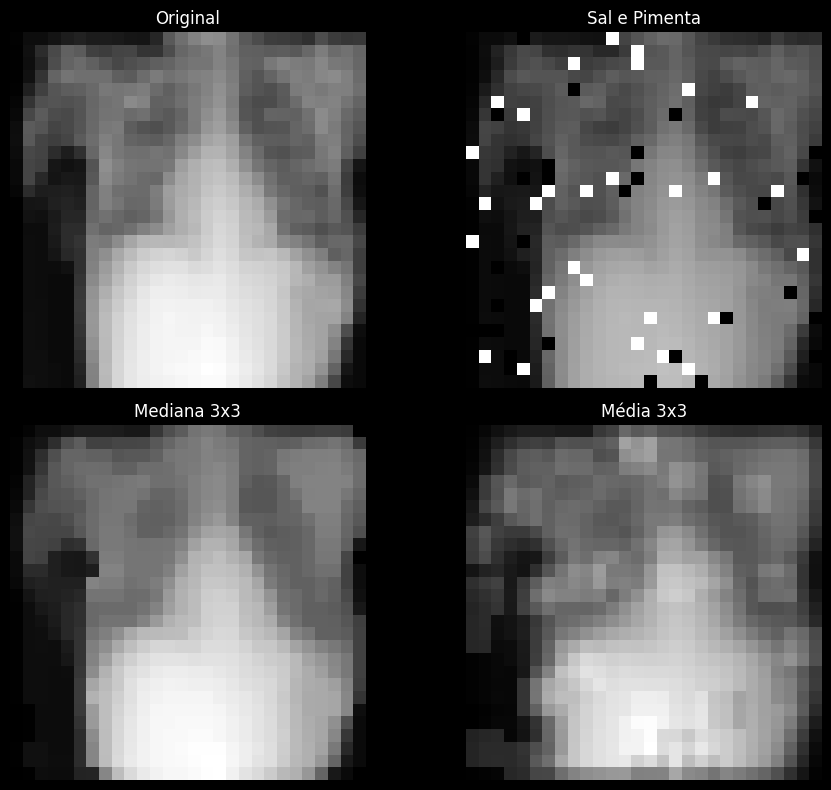

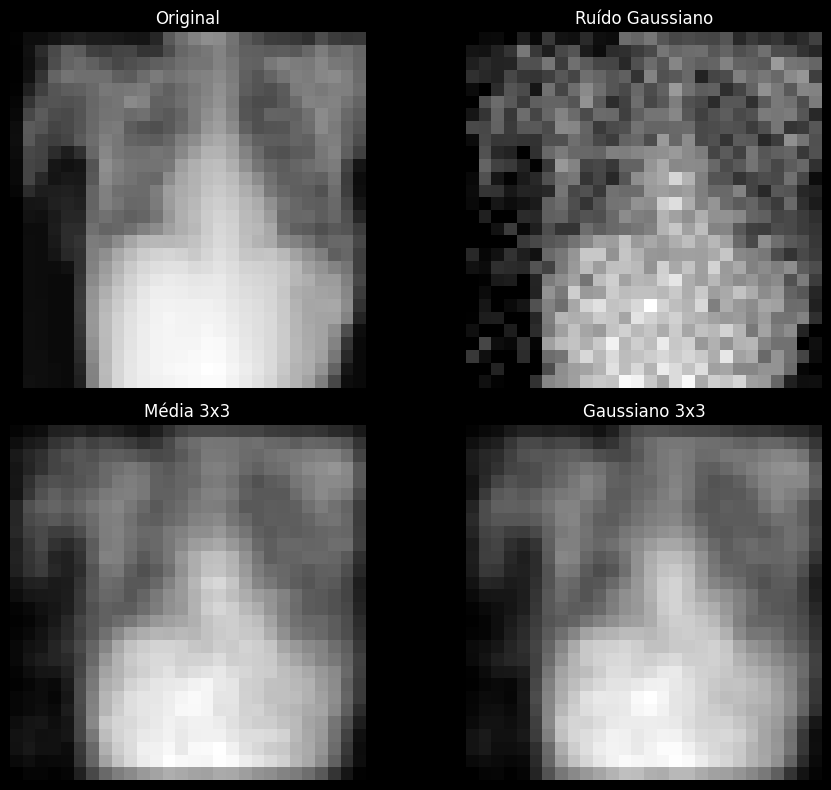

In [24]:
mean_3 = mean_kernel(3)
img_mean = conv2d(img_1_gauss, mean_3)
img_median = median_filter(img_1_sp, size=3)

img_1_sp_median = median_filter(img_1_sp, size=3)
img_1_sp_mean = conv2d(img_1_sp, mean_kernel(3))

show_images_grid(
    [img_1, img_1_sp, img_1_sp_median, img_1_sp_mean],
    ["Original", "Sal e Pimenta", "Mediana 3x3", "Média 3x3"],
    cols=2,
    figsize=(10, 8)
)

img_1_gauss_mean = conv2d(img_1_gauss, mean_kernel(3))
img_1_gauss_gaussian = conv2d(img_1_gauss, gaussian_kernel(3, sigma=1.0))

show_images_grid(
    [img_1, img_1_gauss, img_1_gauss_mean, img_1_gauss_gaussian],
    ["Original", "Ruído Gaussiano", "Média 3x3", "Gaussiano 3x3"],
    cols=2,
    figsize=(10, 8)
)

### 4- Realce de bordas

Laplacian

In [25]:
laplacian_4 = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
], dtype=np.float32)

laplacian_8 = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

In [26]:
def conv2d_float(img, kernel):
    img = img.astype(np.float32)
    kh, kw = kernel.shape
    pad = kh // 2

    padded = add_padding(img, pad)
    h, w = img.shape
    output = np.zeros((h, w), dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)

    return output

In [27]:
def laplacian_sharpen(img, kernel):
    img = img.astype(np.float32)
    lap = conv2d_float(img, kernel)

    sharpened = img + lap
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    return lap, sharpened

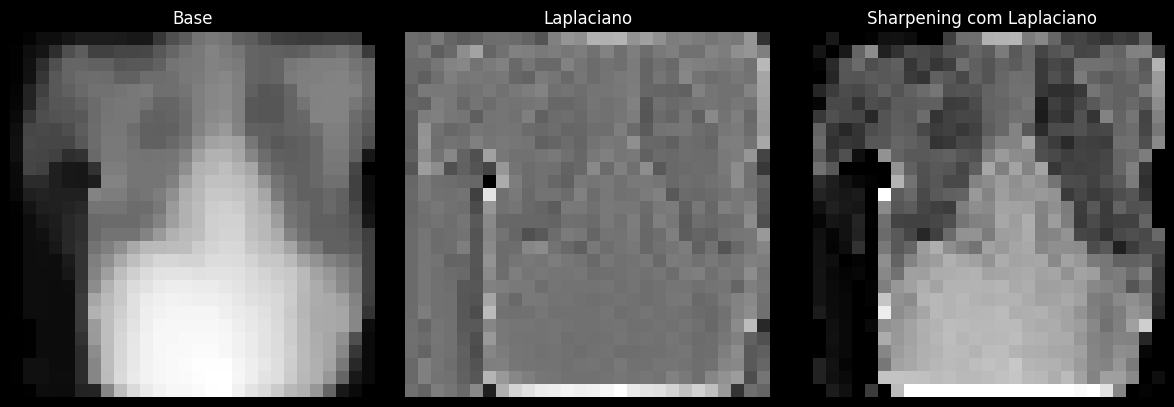

In [28]:
img_base = img_1_sp_median.astype(np.float32)

lap_img, sharp_lap = laplacian_sharpen(img_base, laplacian_4)
lap_img_show = normalize_image(lap_img)

show_images_grid(
    [img_base.astype(np.uint8), lap_img_show, sharp_lap],
    ["Base", "Laplaciano", "Sharpening com Laplaciano"],
    cols=3,
    figsize=(12, 4)
)

### Sobel

In [29]:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

In [30]:
def sobel_edge(img):
    img = img.astype(np.float32)

    gx = conv2d_float(img, sobel_x)
    gy = conv2d_float(img, sobel_y)

    magnitude = np.sqrt(gx**2 + gy**2)

    return gx, gy, magnitude

In [31]:
def sobel_sharpen(img, alpha=1.0):
    img = img.astype(np.float32)

    gx, gy, magnitude = sobel_edge(img)
    magnitude_norm = normalize_image(magnitude).astype(np.float32)

    sharpened = img + alpha * magnitude_norm
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    return gx, gy, magnitude, sharpened

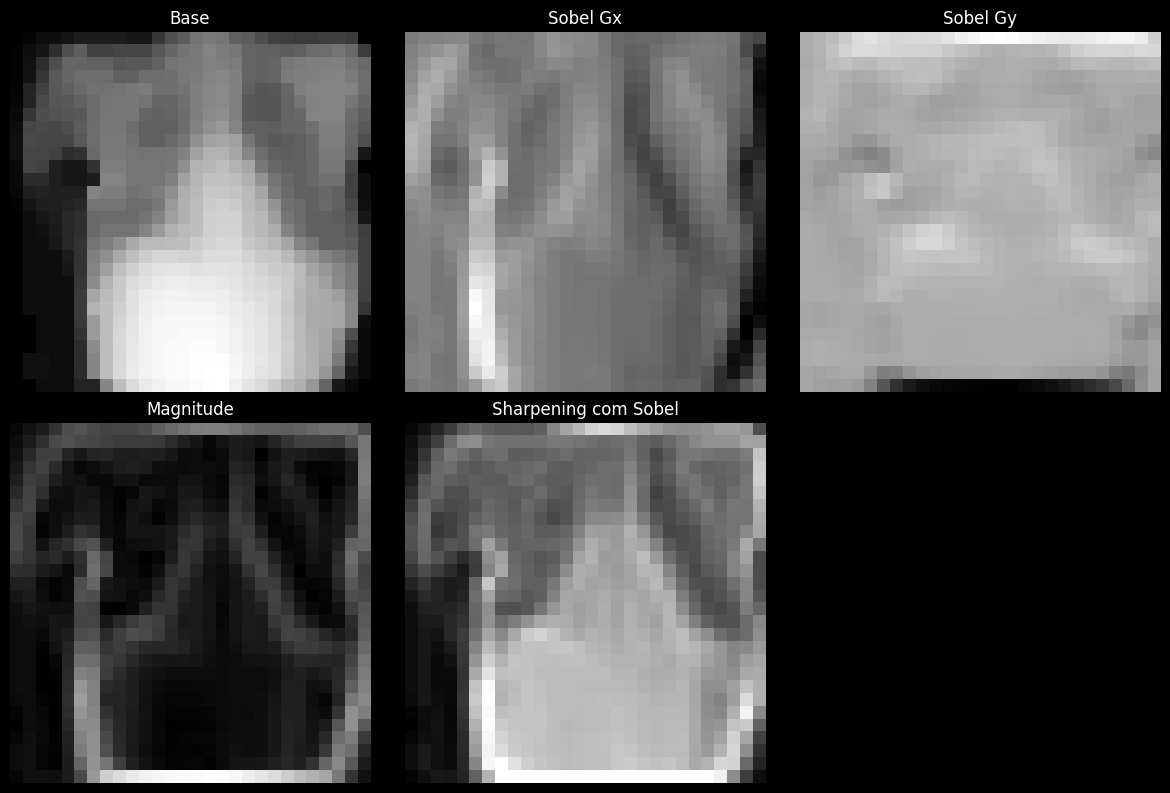

In [32]:
gx, gy, sobel_mag, sharp_sobel = sobel_sharpen(img_base, alpha=1.0)

gx_show = normalize_image(gx)
gy_show = normalize_image(gy)
sobel_show = normalize_image(sobel_mag)

show_images_grid(
    [img_base.astype(np.uint8), gx_show, gy_show, sobel_show, sharp_sobel],
    ["Base", "Sobel Gx", "Sobel Gy", "Magnitude", "Sharpening com Sobel"],
    cols=3,
    figsize=(12, 8)
)

## Pipeline 1

O que observar

No relatório, presta atenção em:

se o contorno ficou mais visível
se o fundo foi preservado
se o ruído voltou a aparecer
se a imagem ficou artificial demais
qual técnica ressaltou melhor a anatomia geral

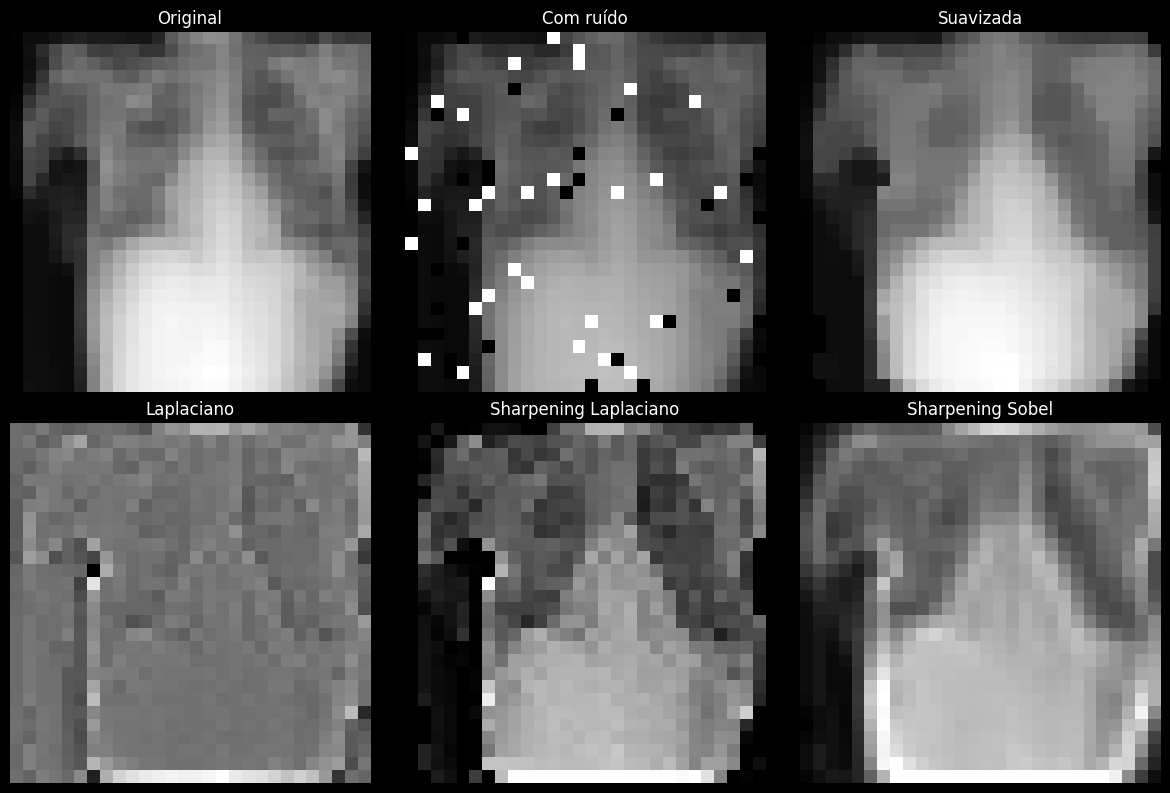

In [33]:
img_original = img_1
img_noisy = img_1_sp
img_denoised = median_filter(img_noisy, size=3)

lap, img_lap_sharp = laplacian_sharpen(img_denoised, laplacian_4)
gx, gy, mag, img_sobel_sharp = sobel_sharpen(img_denoised, alpha=1.0)

show_images_grid(
    [
        img_original,
        img_noisy,
        img_denoised,
        normalize_image(lap),
        img_lap_sharp,
        img_sobel_sharp
    ],
    [
        "Original",
        "Com ruído",
        "Suavizada",
        "Laplaciano",
        "Sharpening Laplaciano",
        "Sharpening Sobel"
    ],
    cols=3,
    figsize=(12, 8)
)

### Ajuste Final

In [34]:
def highboost_filter(img, kernel_size=3, sigma=1.0, k=1.0):
    img = img.astype(np.float32)

    blurred = conv2d_float(img, gaussian_kernel(kernel_size, sigma))
    mask = img - blurred

    sharpened = img + k * mask
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    return blurred, mask, sharpened

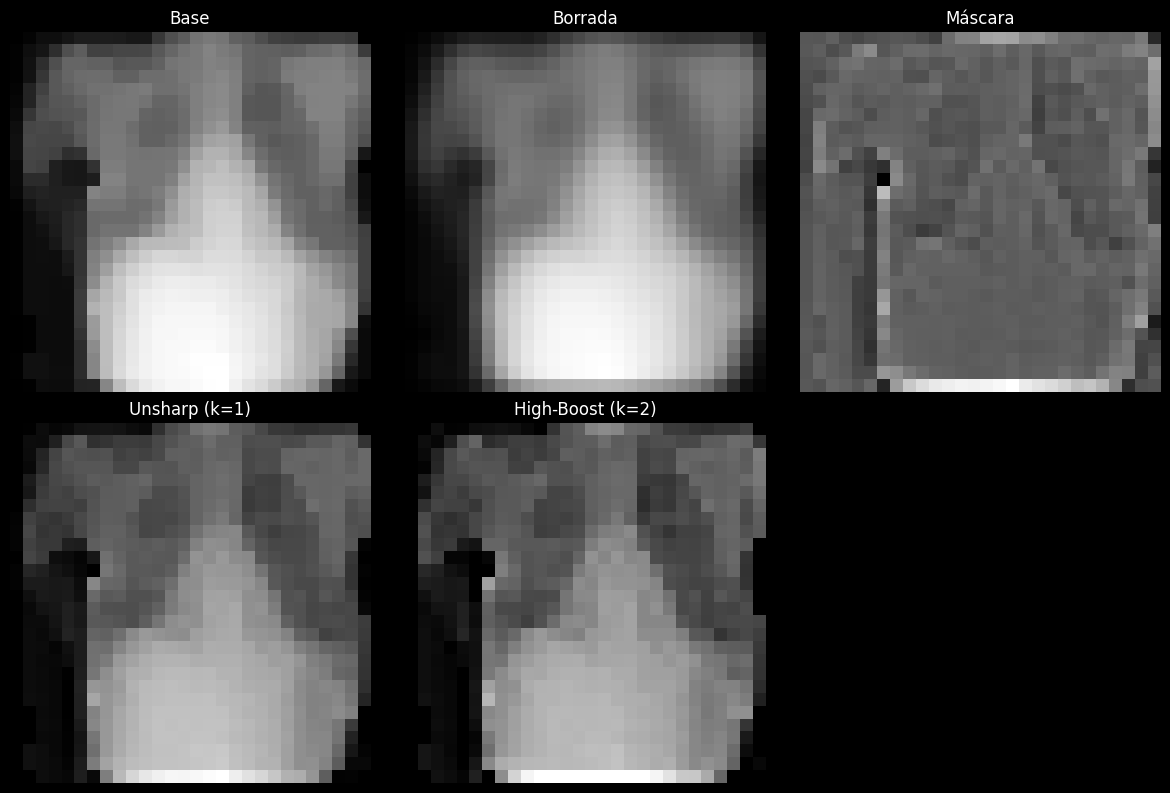

In [35]:
img_base = img_1_sp_median.astype(np.float32)

blurred, mask, unsharp_img = highboost_filter(img_base, kernel_size=3, sigma=1.0, k=1.0)
_, _, highboost_img = highboost_filter(img_base, kernel_size=3, sigma=1.0, k=2.0)

mask_show = normalize_image(mask)
blurred_show = np.clip(blurred, 0, 255).astype(np.uint8)

show_images_grid(
    [img_base.astype(np.uint8), blurred_show, mask_show, unsharp_img, highboost_img],
    ["Base", "Borrada", "Máscara", "Unsharp (k=1)", "High-Boost (k=2)"],
    cols=3,
    figsize=(12, 8)
)

### Pipeline Final

### Pré processamento
- Aplicar equalização de histograma e correção gama para melhorar o contraste.
Lembrando que pode ser escolhido outra técnica.


In [36]:
def pre_process(img):
    img_equalized, img_pre_processed = preprocess_contrast(img)

    return img_equalized, img_pre_processed

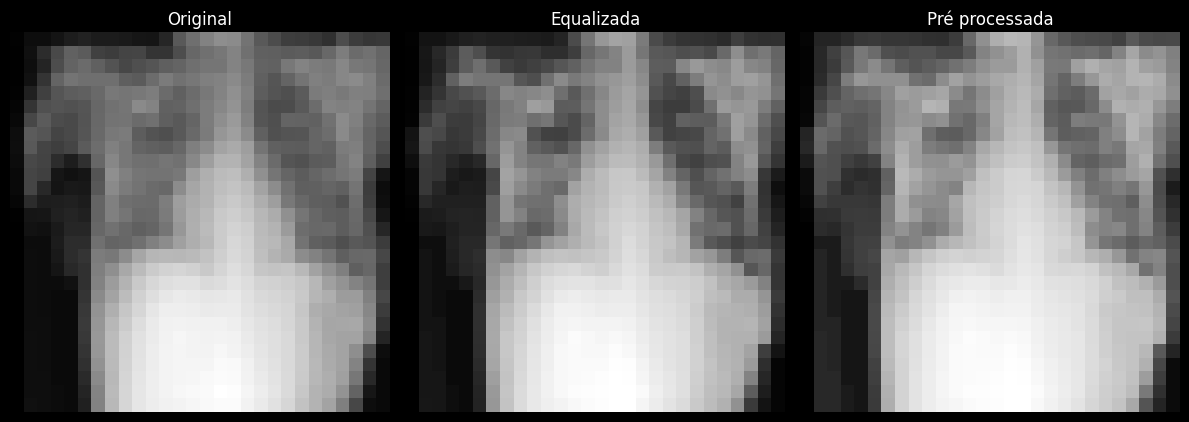

In [37]:
img_original = img_1

img_equalized, img_pre_processed = pre_process(img_original)

show_images_grid(
    [img_original, img_equalized, img_pre_processed],
    ["Original", "Equalizada", "Pré processada"],
    cols=3,
    figsize=(12, 8)
)

### Redução de Ruído
- Aplicar um filtro Gaussiano ou mediana para suavizar a imagem sem perder muitos detalhes

In [38]:
def noisy_reduction(img, method, size=3, sigma=1.0):
    match method:
        case "Gaussian":
            result = conv2d(img, gaussian_kernel(size, sigma))
        case "Median":
            result = median_filter(img, size)
        case "Mean":
            result = conv2d(img, mean_kernel(size))
    return result

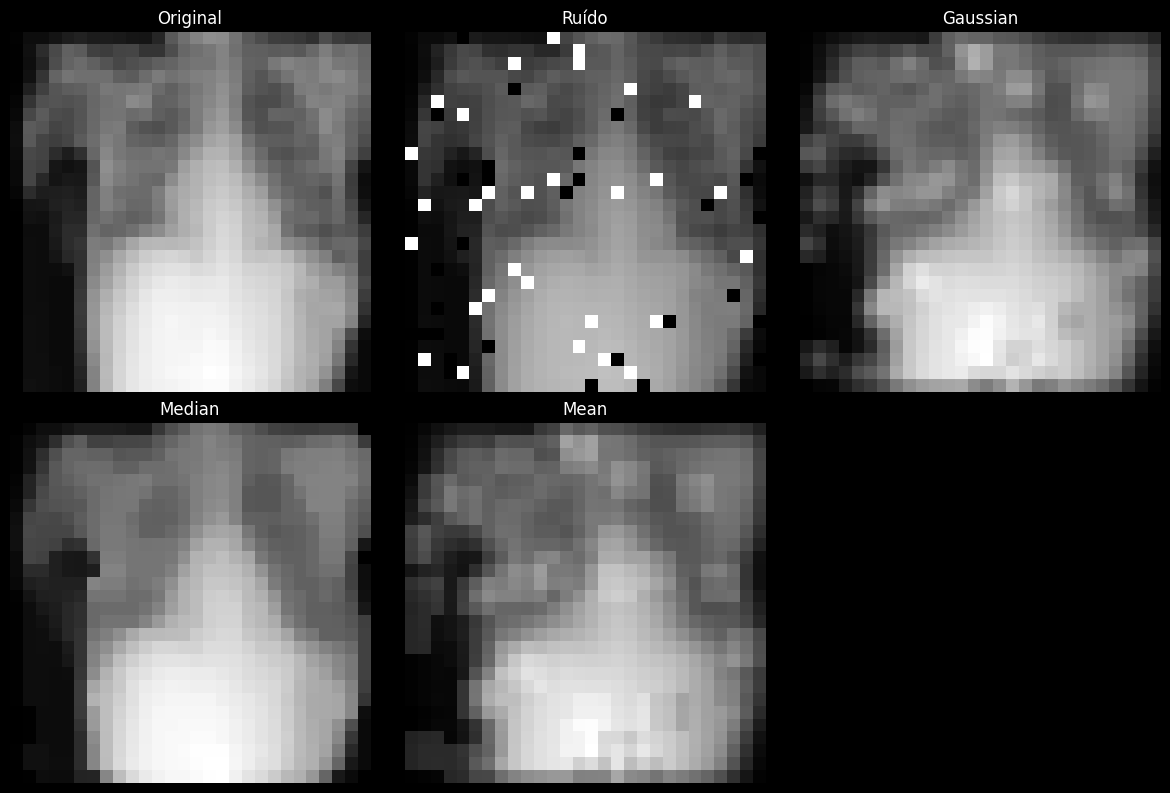

In [39]:
img_original = img_1
img_noisy = img_1_sp

img_denoised_gaussian = noisy_reduction(img_1_sp, method="Gaussian")
img_denoised_median= noisy_reduction(img_1_sp, method="Median")
img_denoised_mean = noisy_reduction(img_1_sp, method="Mean")

show_images_grid(
    [img_original, img_noisy, img_denoised_gaussian, img_denoised_median, img_denoised_mean ],
    ["Original", "Ruído", "Gaussian", "Median", "Mean"],
    cols=3,
    figsize=(12, 8)
)

imagem original
imagem com ruido

- seq 1
img = pre processar()
img = tirar ruido()
img = realcar bordas()
img = highboost

img = analisar_metricas()

- seq 2
img = tirar ruido()
img = pre processar()
img = realcar bordas()
img = highboost


- seq 3
img = tirar ruido()
img = realcar bordas()
img = pre processar()
img = highboost

### Realce de bordas
- Aplicar um filtro Laplaciano ou operador de Sobel para destacar contornos importantes

In [40]:
def edge_enhancment(img, method, laplacian=laplacian_4):
    match method:
        case "Laplacian":
            _, result = laplacian_sharpen(img, laplacian)
        case "Sobel":
            _, _, _, result = sobel_sharpen(img)
    return result

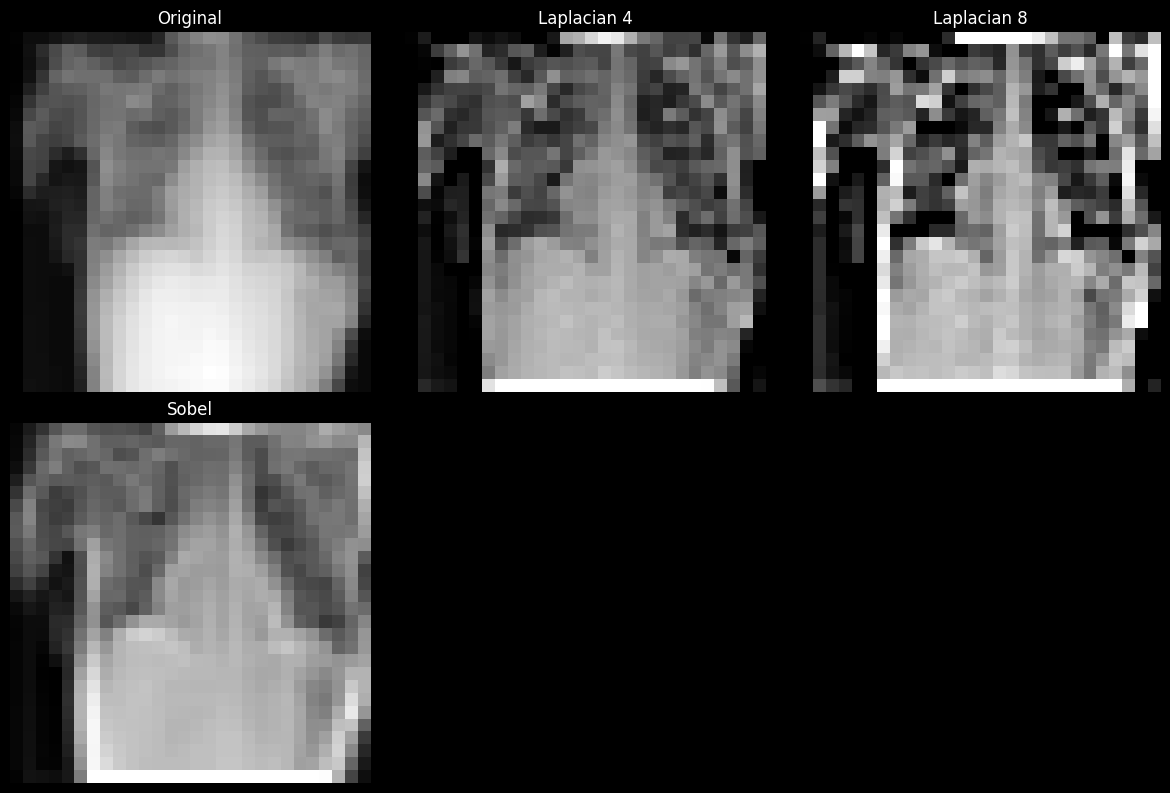

In [41]:
img_original = img_1

img_laplacian_4 = edge_enhancment(img_original, "Laplacian")
img_laplacian_8 = edge_enhancment(img_original, "Laplacian", laplacian_8)
img_sobel = edge_enhancment(img_original, "Sobel")

show_images_grid(
    [img_original, img_laplacian_4, img_laplacian_8, img_sobel],
    ["Original", "Laplacian 4", "Laplacian 8", "Sobel"],
    cols=3,
    figsize=(12, 8)
)

### HighBoost Filtering
- Reforçar detalhes combinando a imagem original com a filtrada para um realce equilibrado

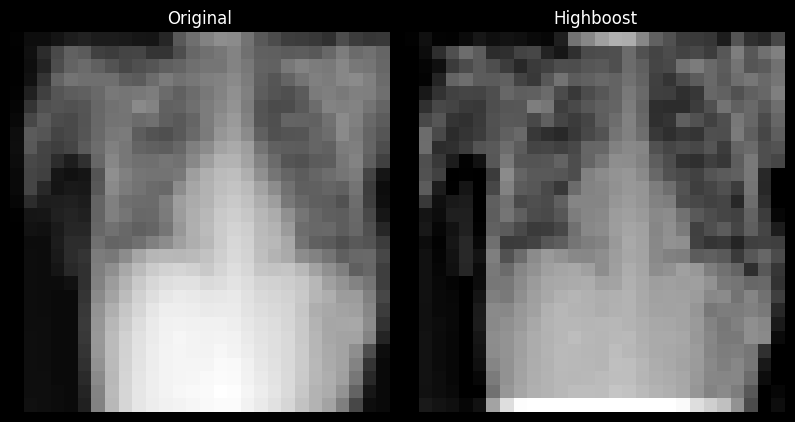

In [42]:
img_original = img_1
_, _, img_final = highboost_filter(img_original, kernel_size=3, sigma=1.0, k=2.0)

show_images_grid(
    [img_original, img_final],
    ["Original", "Highboost"]
)

# Pipeline

- Aplicar cada passo

In [43]:
def apply_step(img, step_name, params=None):
    if params is None:
        params = {}

    match step_name:
        case "preprocess":
            _, result = pre_process(img)
            return result

        case "denoise":
            method = params.get("method", "Gaussian")
            size = params.get("size", 3)
            sigma = params.get("sigma", 1.0)
            return noisy_reduction(img, method, size=size, sigma=sigma)

        case "edge":
            method = params.get("method", "Laplacian")
            laplacian = params.get("laplacian", laplacian_4)
            return edge_enhancment(img, method, laplacian=laplacian)

        case "highboost":
            kernel_size = params.get("kernel_size", 3)
            sigma = params.get("sigma", 1.0)
            k = params.get("k", 2.0)
            _, _, result = highboost_filter(img, kernel_size=kernel_size, sigma=sigma, k=k)

- Rodar a Pipeline

In [50]:
def run_pipeline(original_img, noisy_img, sequence, config=None):
    if config is None:
        config = {}

    current = noisy_img.copy()
    history = {
        "original": original_img,
        "noisy": noisy_img,
    }

    # Começa a implementar cada passo
    for step in sequence:
        params = config.get(step, {})
        current = apply_step(current, step, params)
        history[step] = current

    history["final"] = current

    return history

- Configurações

In [54]:
config = {
    "preprocess": {},
    "denoise": {
        "method": "Median",
        "size": 3,
        "sigma": 1.0
    },
    "edge": {
        "method": "Sobel",
    },
    "highboost": {
        "kernel_size": 3,
        "sigma": 1.0,
        "k": 1.5
    }
}

- Sequências

In [55]:
seq1 = ["preprocess", "denoise", "edge", "highboost"]
seq2 = ["denoise", "preprocess", "edge", "highboost"]
seq3 = ["denoise", "edge", "preprocess", "highboost"]

result_seq1 = run_pipeline(
    original_img=img_original,
    noisy_img=img_noisy,
    sequence=seq1,
    config=config,
)

result_seq2 = run_pipeline(
    original_img=img_original,
    noisy_img=img_noisy,
    sequence=seq2,
    config=config,
)

result_seq3 = run_pipeline(
    original_img=img_original,
    noisy_img=img_noisy,
    sequence=seq3,
    config=config,
)

- Plotando as sequências

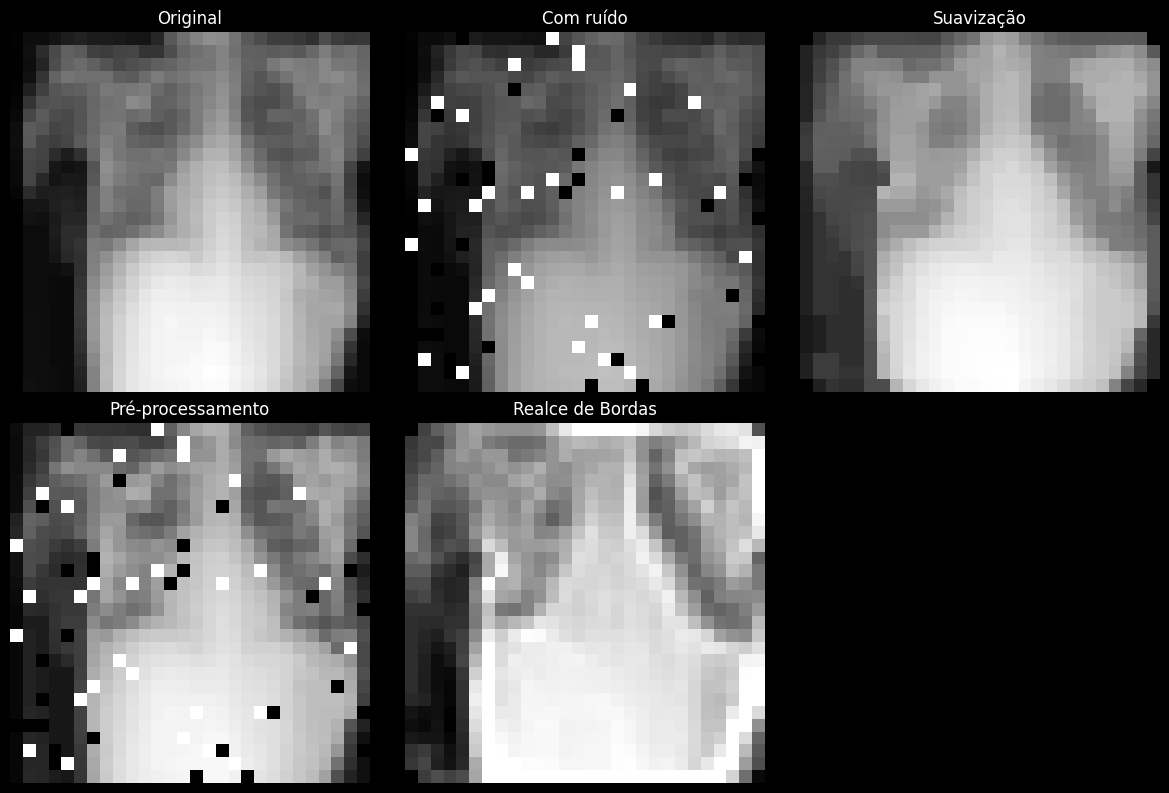


=== Sequência 1: preprocess → denoise → edge → highboost ===


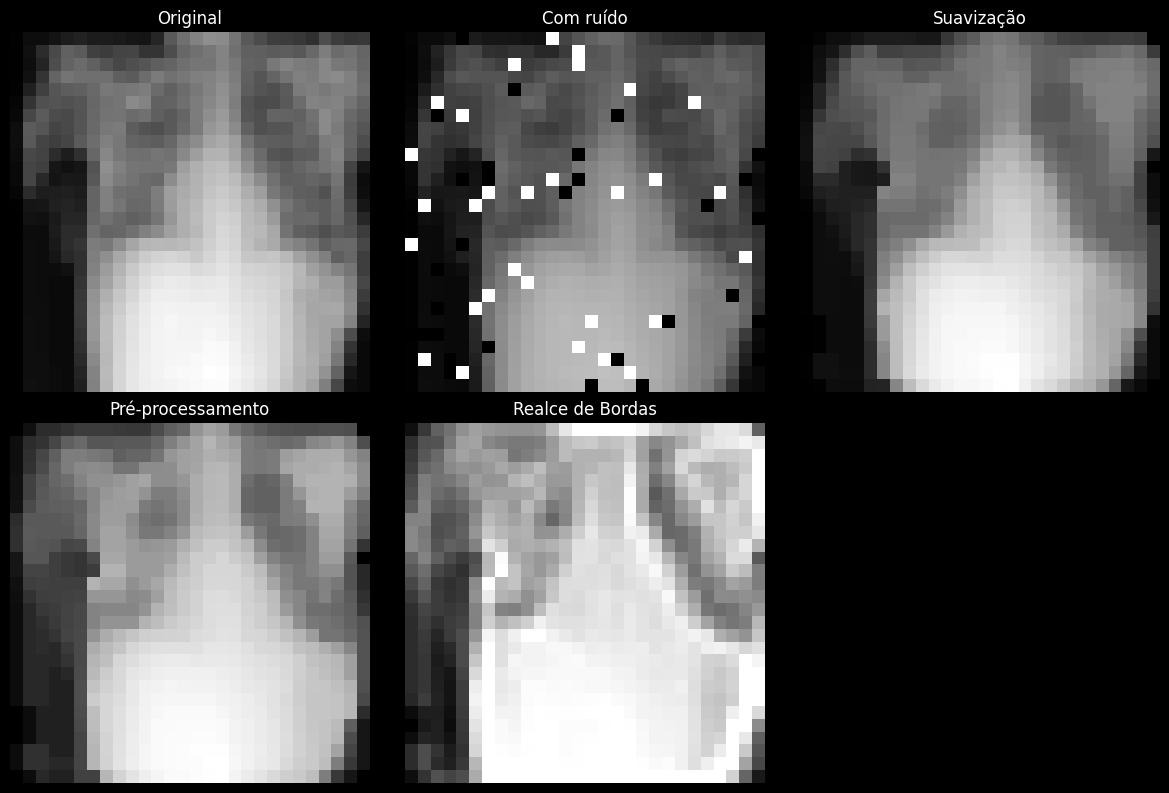


=== Sequência 2: denoise → preprocess → edge → highboost ===


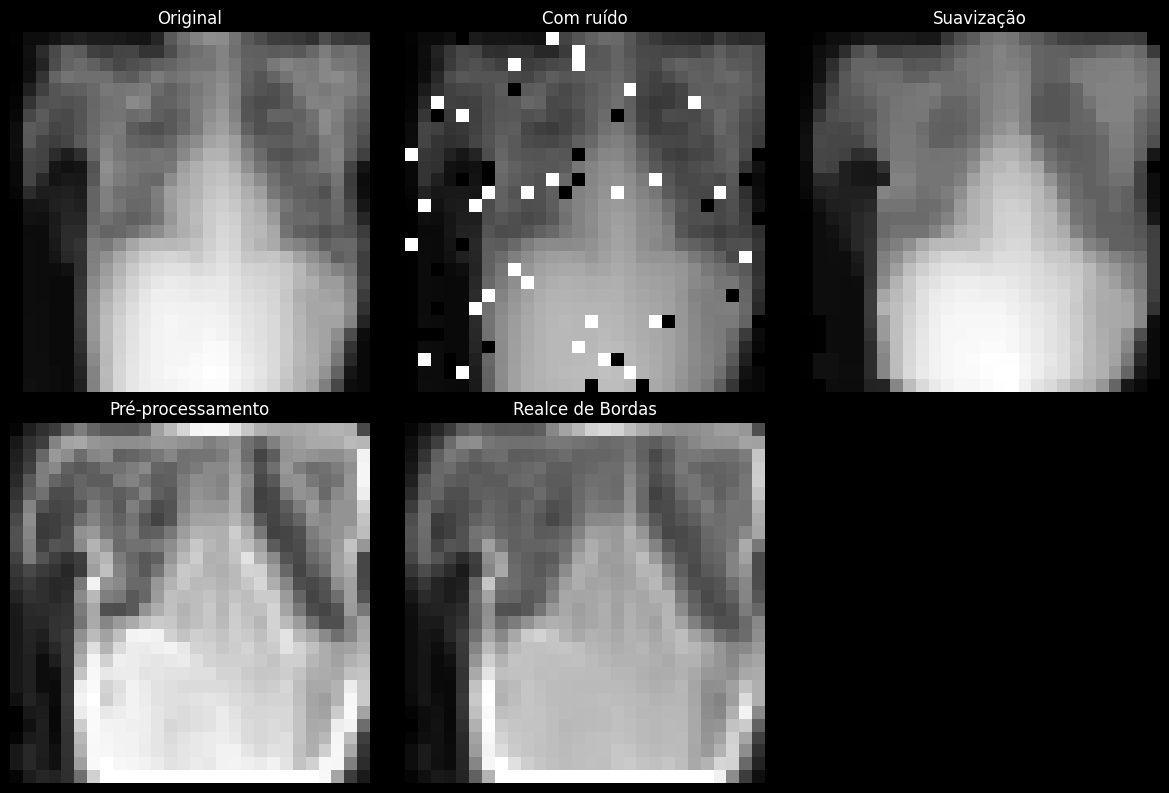


=== Sequência 3: denoise → edge → preprocess → highboost ===


In [56]:
def plot_sequence(history, title="Pipeline"):
    images = [
        history["original"],
        history["noisy"],
        history.get("denoise"),
        history.get("preprocess"),
        history.get("edge"),
        history.get("highboost"),
        history.get("final")
    ]

    titles = [
        "Original",
        "Com ruído",
        "Suavização",
        "Pré-processamento",
        "Realce de Bordas",
        "High-Boost",
        "Final"
    ]

    # Remove etapas que não existem (caso a sequência mude)
    images_filtered = []
    titles_filtered = []

    for img, t in zip(images, titles):
        if img is not None:
            images_filtered.append(img)
            titles_filtered.append(t)

    show_images_grid(
        images_filtered,
        titles_filtered,
        cols=3,
        figsize=(12, 8)
    )

    print(f"\n=== {title} ===")
    if "metrics" in history:
        for k, v in history["metrics"].items():
            print(f"{k.upper()}: {v}")


# Plotando as 3 sequências
plot_sequence(result_seq1, "Sequência 1: preprocess → denoise → edge → highboost")
plot_sequence(result_seq2, "Sequência 2: denoise → preprocess → edge → highboost")
plot_sequence(result_seq3, "Sequência 3: denoise → edge → preprocess → highboost")